# Projeto Final de PLN – Classificação de Editais por Macroárea com TF-IDF + SVM e Sumarização com PTT5

**Tema:** classificação de editais por **área de gasto público** e sumarização de editais em linguagem cidadã.

**Ideia central:** usar PLN para apoiar transparência ativa nas contratações públicas. O pipeline usa a base pública do repositório do grupo, aplica **TF-IDF + SVM** para classificar os editais em macroáreas como Saúde, Saneamento, Segurança, Educação, Infraestrutura/Obras e Administração/Outros, e propõe **PTT5** para gerar resumos em linguagem cidadã.

# 1. Contexto e problema real

A Administração Pública publica diariamente grande volume de editais de licitação. Esses documentos são essenciais para garantir publicidade, concorrência e controle social. Entretanto, a linguagem dos editais tende a ser extensa, técnica e jurídica, criando uma barreira de compreensão para cidadãos, pequenos fornecedores e microempresas.

O problema real investigado neste projeto é: **como usar PLN para transformar editais de contratação pública em resumos executivos claros, acessíveis e úteis para a sociedade?**

A hipótese do grupo é que técnicas modernas de PLN, especialmente modelos Transformer e LLMs, conseguem reduzir a complexidade textual dos editais sem eliminar informações essenciais. O produto esperado não substitui o edital oficial, mas funciona como uma camada de acesso inicial, facilitando a compreensão do objeto da contratação, do órgão responsável, dos potenciais interessados e das condições principais.

## Pergunta de pesquisa

> Modelos de PLN conseguem gerar resumos de editais de contratação pública em linguagem cidadã com fidelidade suficiente ao documento original e clareza superior ao texto bruto?

## Potencial impacto aplicado

- Aumentar a transparência ativa nas contratações públicas.
- Facilitar o controle social por cidadãos não especialistas.
- Apoiar micro e pequenas empresas na triagem de oportunidades.
- Criar uma ferramenta de comunicação pública alinhada ao princípio da linguagem simples.


# 2. Alinhamento com os requisitos do projeto final

Este projeto se enquadra na **Modalidade 2 — PLN no Setor Público**, pois utiliza dados textuais de licitações públicas e aplica técnicas de Processamento de Linguagem Natural para resolver um problema real de transparência administrativa.

O trabalho atende aos principais requisitos esperados:

- identificação de um problema real tratável por PLN;
- uso de dados textuais coletados a partir de fonte pública;
- aplicação de técnicas como scraping, extração de texto, sumarização, LLMs, Transformers e engenharia de prompt;
- avaliação dos resultados com métricas automáticas e avaliação qualitativa/manual;
- discussão de limitações, riscos e uso responsável da IA;
- organização do repositório com notebook, scripts, dados e documentação.

## Entregáveis sugeridos

1. Notebook `.ipynb` com o pipeline completo.
2. Script de coleta dos editais.
3. Arquivo com a base tratada.
4. Arquivo com os resumos gerados.
5. README do repositório.
6. Slides em PDF para apresentação final.


# 3. Dados

A base principal do projeto é carregada diretamente do repositório público do grupo no GitHub, sem depender de arquivo local no computador do aluno.

Fonte direta da base:

```text
https://raw.githubusercontent.com/primodeckers/deep-learning-pln-project/main/data/raw/licitacoes2025.csv
```

A base `licitacoes2025.csv` indexa licitações públicas do Distrito Federal em 2025. Segundo a documentação do próprio repositório, o CSV fica em `data/raw/`, contém 437 linhas e 423 URLs únicas, e a coluna `Edital` aponta para o corpus textual usado no projeto.

O escopo da classificação foi alterado para seguir a proposta do grupo em `docs/PROPOSALS.md`, o classificador tenta prever **macroáreas de gasto público** a partir do texto do edital. As macroáreas propostas são:

- Saúde
- Saneamento
- Segurança
- Educação
- Infraestrutura / Obras
- Administração / Outros

Como sugerido no documento do grupo, o rótulo inicial é gerado pragmaticamente a partir do **órgão** da licitação, funcionando como weak labeling. O modelo, porém, é treinado com foco no **texto do objeto**, e não no nome do órgão, para reduzir risco de vazamento de informação.

Para a classificação, o pipeline usa **TF-IDF + SVM** (sklearn): vetorização por frequência de termos com TF-IDF e classificação via Support Vector Machine. Para a sumarização abstrativa, o notebook usa **PTT5**.


In [1]:
# ============================================================
# 1. Importações e configuração geral
# ============================================================

!pip install pypdf
from pathlib import Path
import re
import json
import time
import unicodedata
from urllib.parse import urlparse

import numpy as np
import pandas as pd

import requests
from bs4 import BeautifulSoup
from pypdf import PdfReader
from tqdm.auto import tqdm

SEED = 42
np.random.seed(SEED)

# Repositório público do grupo
REPO_URL = 'https://github.com/primodeckers/deep-learning-pln-project'

# Base bruta lida diretamente do GitHub, sem depender de upload local.
CSV_URL = (
    'https://raw.githubusercontent.com/'
    'primodeckers/deep-learning-pln-project/main/data/raw/licitacoes2025.csv'
)

# Modelo de sumarização
PTT5_MODEL_NAME = 'unicamp-dl/ptt5-base-portuguese-vocab'

# Flags de execução.
# Deixe False para rodar o notebook rapidamente.
# Mude para True quando quiser treinar/gerar com os modelos.
RUN_TFIDF_SVM_TRAINING = True
RUN_PTT5_SUMMARIZATION = True

DATA_DIR = Path('data')
RAW_DIR = DATA_DIR / 'raw_editais'
PROCESSED_DIR = DATA_DIR / 'processed'

DATA_DIR.mkdir(exist_ok=True)
RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print('Diretório atual:', Path.cwd())
print('Repositório do projeto:', REPO_URL)
print('CSV carregado diretamente de:', CSV_URL)
print('Classificação com: TF-IDF + SVM')
print('Sumarização com:', PTT5_MODEL_NAME)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.0/349.0 kB 24.9 MB/s eta 0:00:00
Diretório atual: /content
Repositório do projeto: https://github.com/primodeckers/deep-learning-pln-project
CSV carregado diretamente de: https://raw.githubusercontent.com/primodeckers/deep-learning-pln-project/main/data/raw/licitacoes2025.csv
Classificação com: TF-IDF + SVM
Sumarização com: unicamp-dl/ptt5-base-portuguese-vocab


# 4. Carregamento e inspeção da planilha de licitações

A planilha possui uma primeira linha de título e, a partir da segunda linha, o cabeçalho real das colunas. Por isso, a leitura usa `skiprows=1` e separador `;`.

Nesta etapa, o objetivo é carregar a base, remover colunas vazias, padronizar os nomes das colunas e verificar o volume inicial de registros.


In [2]:
# ============================================================
# 2. Leitura robusta da base diretamente do GitHub
# ============================================================

def normalizar_nome_coluna(col):
    col = str(col).strip()
    col = unicodedata.normalize('NFKD', col).encode('ascii', 'ignore').decode('utf-8')
    col = col.lower()
    col = re.sub(r'[^a-z0-9]+', '_', col)
    col = re.sub(r'_+', '_', col).strip('_')
    return col


def carregar_licitacoes(url=CSV_URL):
    """Carrega a base `licitacoes2025.csv` diretamente do GitHub.

    Observação técnica:
    - o arquivo usa separador `;`;
    - a primeira linha é um título da base;
    - a segunda linha contém o cabeçalho real.
    """
    df = pd.read_csv(
        url,
        sep=';',
        skiprows=1,
        encoding='utf-8-sig',
        dtype=str,
        engine='python'
    )

    df = df.loc[:, ~df.columns.astype(str).str.contains('^Unnamed', regex=True)]
    df.columns = [normalizar_nome_coluna(c) for c in df.columns]
    df = df.dropna(how='all').copy()

    for col in df.columns:
        df[col] = df[col].astype(str).str.strip()
        df[col] = df[col].replace({'nan': np.nan, 'None': np.nan, '': np.nan})

    return df


licitacoes = carregar_licitacoes(CSV_URL)

print('Formato da base:', licitacoes.shape)
print('Colunas:', list(licitacoes.columns))

display(licitacoes.head())


Formato da base: (437, 9)
Colunas: ['no_da_licitacao', 'modalidade', 'situacao', 'orgao', 'codigo_comprasnet', 'tipo', 'objeto', 'edital', 'total_homologado']


,no_da_licitacao,modalidade,situacao,orgao,codigo_comprasnet,tipo,objeto,edital,total_homologado
0,90119/2025,PREGÃO,DIVULGADO,SECRETARIA DE ESTADO DE SAÚDE - DF,926119,MATERIAL,OBJETO: PREGÃO ELETRÔNICO - AQUISIÇÃO DOS MED...,http://www.comprasnet.gov.br/ConsultaLicitacoe...,"62.800,00"
1,90115/2025,PREGÃO,DIVULGADO,SECRETARIA DE ESTADO DE SAÚDE - DF,926119,MATERIAL,OBJETO: PREGÃO ELETRÔNICO - PROCESSO PARA POT...,http://www.comprasnet.gov.br/ConsultaLicitacoe...,"607.671,00"
2,90114/2025,PREGÃO,DIVULGADO,SECRETARIA DE ESTADO DE SAÚDE - DF,926119,MATERIAL,OBJETO: PREGÃO ELETRÔNICO - AQUISIÇÃO REGULAR...,http://www.comprasnet.gov.br/ConsultaLicitacoe...,"188.808,00"
3,90113/2025,PREGÃO,DIVULGADO,SECRETARIA DE ESTADO DE SAÚDE - DF,926119,MATERIAL,OBJETO: PREGÃO ELETRÔNICO - AQUISIÇÃO DE CAPE...,http://www.comprasnet.gov.br/ConsultaLicitacoe...,"74.400,00"
4,90109/2025,PREGÃO,DIVULGADO,SECRETARIA DE ESTADO DE SAÚDE - DF,926119,MATERIAL,OBJETO: PREGÃO ELETRÔNICO - AQUISIÇÃO REGULAR...,http://www.comprasnet.gov.br/ConsultaLicitacoe...,"11.278,00"


### 5. Limpeza inicial e criação de variáveis tabulares

Antes da extração do texto integral dos editais, a própria planilha já permite construir variáveis úteis para análise e modelagem. Nesta etapa, foi aplicada uma limpeza inicial no campo do objeto da licitação, com remoção de expressões repetitivas, normalização de espaços e, principalmente, exclusão explícita do nome do órgão e de prefixos como “Órgão:”, a fim de reduzir vazamento de informação na tarefa de classificação por macroárea. O resultado dessa etapa é a variável `objeto_limpo`, que preserva o conteúdo substantivo do edital sem carregar diretamente a identidade institucional do órgão.

Também foram criadas variáveis tabulares auxiliares. A variável `total_homologado_num` converte o valor homologado para formato numérico, permitindo futuras análises quantitativas. A variável `tem_link_edital` indica se o registro possui link válido para o edital completo, o que é importante para a etapa de coleta textual. Já a variável `dominio_edital` identifica o domínio da URL, permitindo mapear as principais fontes de coleta e avaliar a heterogeneidade dos portais utilizados.

Essas variáveis cumprem duas funções no projeto. Primeiro, ajudam a descrever e auditar a base de dados. Segundo, podem ser usadas como contexto complementar em etapas posteriores, especialmente na sumarização, sem comprometer a integridade metodológica da classificação textual, já que o nome do órgão foi removido do conteúdo textual usado como entrada do classificador.

In [3]:
# ============================================================
# 3. Limpeza inicial — versão anti-vazamento
# ============================================================

def normalizar_texto(txt):
    if pd.isna(txt):
        return ''
    txt = str(txt)
    txt = unicodedata.normalize('NFKD', txt).encode('ascii', 'ignore').decode('utf-8')
    txt = re.sub(r'\s+', ' ', txt)
    return txt.strip()


def gerar_variantes_orgao(orgao):
    """
    Gera variantes do nome do órgão para remoção robusta do texto.
    """
    orgao_original = '' if pd.isna(orgao) else str(orgao).strip()
    orgao_norm = normalizar_texto(orgao_original)

    variantes = set()

    for item in [orgao_original, orgao_norm]:
        if item:
            variantes.add(item)
            variantes.add(item.upper())
            variantes.add(item.lower())

    # Remove prefixos administrativos muito comuns para facilitar match
    bases = list(variantes)
    for item in bases:
        limpo = re.sub(
            r'^(EDF\s*-\s*|GDF\s*-\s*|SECRETARIA DE ESTADO DE\s+|SECRETARIA\s+DE\s+|ADMINISTRACAO REGIONAL DO\s+|ADMINISTRACAO REGIONAL DE\s+|ADMINISTRAÇÃO REGIONAL DO\s+|ADMINISTRAÇÃO REGIONAL DE\s+)',
            '',
            item,
            flags=re.IGNORECASE
        ).strip()
        if limpo:
            variantes.add(limpo)

    variantes = [v.strip() for v in variantes if v and v.strip()]
    variantes = sorted(set(variantes), key=len, reverse=True)

    return variantes


def remover_orgao_do_texto(texto, orgao):
    """
    Remove explicitamente o nome do órgão e padrões do tipo 'Órgão: ...'
    """
    if pd.isna(texto):
        return ''

    texto = str(texto)

    # Remove linhas / prefixos explícitos de órgão
    texto = re.sub(r'Órgão\s*:\s*[^\n\r.]+[.\n\r]?', ' ', texto, flags=re.IGNORECASE)
    texto = re.sub(r'Orgao\s*:\s*[^\n\r.]+[.\n\r]?', ' ', texto, flags=re.IGNORECASE)

    # Remove variantes do órgão
    for variante in gerar_variantes_orgao(orgao):
        padrao = re.escape(variante)
        texto = re.sub(padrao, ' ', texto, flags=re.IGNORECASE)

    # Normalizações finais
    texto = re.sub(r'\s+', ' ', texto)
    texto = re.sub(r'\s+([,.;:])', r'\1', texto)
    texto = re.sub(r'^[,.;:\-\s]+', '', texto)
    texto = re.sub(r'[,.;:\-\s]+$', '', texto)

    return texto.strip()


def limpar_texto_basico(texto, orgao=None):
    if pd.isna(texto):
        return ''

    texto = str(texto)

    # Remove prefixos comuns
    texto = re.sub(r'^\s*OBJETO\s*:\s*', '', texto, flags=re.IGNORECASE)
    texto = re.sub(r'\s+', ' ', texto).strip()

    # Remove órgão explicitamente
    texto = remover_orgao_do_texto(texto, orgao)

    return texto.strip()


def valor_brasileiro_para_float(valor):
    if pd.isna(valor):
        return np.nan
    valor = str(valor).strip()
    valor = re.sub(r'[^0-9,.-]', '', valor)
    if not valor:
        return np.nan
    valor = valor.replace('.', '').replace(',', '.')
    try:
        return float(valor)
    except ValueError:
        return np.nan


def extrair_dominio(url):
    if pd.isna(url):
        return np.nan
    try:
        return urlparse(str(url)).netloc
    except Exception:
        return np.nan


# Limpeza do objeto SEM o nome do órgão
licitacoes['objeto_limpo'] = licitacoes.apply(
    lambda row: limpar_texto_basico(row.get('objeto', ''), row.get('orgao', '')),
    axis=1
)

licitacoes['total_homologado_num'] = licitacoes['total_homologado'].apply(valor_brasileiro_para_float)
licitacoes['tem_link_edital'] = licitacoes['edital'].notna() & licitacoes['edital'].astype(str).str.startswith('http', na=False)
licitacoes['dominio_edital'] = licitacoes['edital'].apply(extrair_dominio)

print('Registros com link de edital:', int(licitacoes['tem_link_edital'].sum()))
print('Domínios mais frequentes:')
display(licitacoes['dominio_edital'].value_counts().head(10))

display(
    licitacoes[
        ['no_da_licitacao', 'modalidade', 'situacao', 'orgao', 'tipo', 'objeto_limpo', 'edital', 'total_homologado_num']
    ].head()
)

Registros com link de edital: 437
Domínios mais frequentes:


,count
dominio_edital,
www.comprasnet.gov.br,437


,no_da_licitacao,modalidade,situacao,orgao,tipo,objeto_limpo,edital,total_homologado_num
0,90119/2025,PREGÃO,DIVULGADO,SECRETARIA DE ESTADO DE SAÚDE - DF,MATERIAL,PREGÃO ELETRÔNICO - AQUISIÇÃO DOS MEDICAMENTO(...,http://www.comprasnet.gov.br/ConsultaLicitacoe...,62800.0
1,90115/2025,PREGÃO,DIVULGADO,SECRETARIA DE ESTADO DE SAÚDE - DF,MATERIAL,PREGÃO ELETRÔNICO - PROCESSO PARA POTENCIAL CO...,http://www.comprasnet.gov.br/ConsultaLicitacoe...,607671.0
2,90114/2025,PREGÃO,DIVULGADO,SECRETARIA DE ESTADO DE SAÚDE - DF,MATERIAL,PREGÃO ELETRÔNICO - AQUISIÇÃO REGULAR DE INSUM...,http://www.comprasnet.gov.br/ConsultaLicitacoe...,188808.0
3,90113/2025,PREGÃO,DIVULGADO,SECRETARIA DE ESTADO DE SAÚDE - DF,MATERIAL,PREGÃO ELETRÔNICO - AQUISIÇÃO DE CAPELA DE FLU...,http://www.comprasnet.gov.br/ConsultaLicitacoe...,74400.0
4,90109/2025,PREGÃO,DIVULGADO,SECRETARIA DE ESTADO DE SAÚDE - DF,MATERIAL,PREGÃO ELETRÔNICO - AQUISIÇÃO REGULAR DE INSUM...,http://www.comprasnet.gov.br/ConsultaLicitacoe...,11278.0


# 6. Coleta dos editais por scraping ou download

A coleta deve ser feita de forma responsável: usar `timeout`, limitar a amostra inicial durante testes, salvar os documentos brutos para reprodutibilidade, registrar falhas de download e respeitar boas práticas de acesso ao portal consultado.

A função abaixo tenta baixar o conteúdo do link do edital e salvar em disco. Em alguns portais, o link pode levar a uma página intermediária, e não diretamente ao PDF. Por isso, o código trata tanto conteúdo HTML quanto PDF.


In [4]:
# ============================================================
# 4. Download controlado dos editais
# ============================================================

HEADERS = {
    'User-Agent': 'Mozilla/5.0 (compatible; projeto-academico-pln-editais/1.0)'
}


def extensao_por_content_type(content_type, url):
    content_type = (content_type or '').lower()
    if 'pdf' in content_type or str(url).lower().endswith('.pdf'):
        return '.pdf'
    if 'html' in content_type or 'text' in content_type:
        return '.html'
    return '.bin'


def baixar_edital(url, licitacao_id, pasta=RAW_DIR, sleep=0.5):
    # Baixa um edital e retorna metadados do download.
    meta = {
        'licitacao_id': licitacao_id,
        'url': url,
        'status_code': None,
        'content_type': None,
        'arquivo_local': None,
        'erro': None
    }

    try:
        time.sleep(sleep)
        resp = requests.get(url, headers=HEADERS, timeout=30, allow_redirects=True)
        meta['status_code'] = resp.status_code
        meta['content_type'] = resp.headers.get('Content-Type', '')

        if resp.status_code != 200:
            meta['erro'] = f'HTTP {resp.status_code}'
            return meta

        ext = extensao_por_content_type(meta['content_type'], url)
        nome_seguro = re.sub(r'[^a-zA-Z0-9_-]+', '_', str(licitacao_id))[:80]
        path = pasta / f'{nome_seguro}{ext}'
        path.write_bytes(resp.content)

        meta['arquivo_local'] = str(path)
        return meta

    except Exception as e:
        meta['erro'] = repr(e)
        return meta


amostra_links = licitacoes[licitacoes['tem_link_edital']].head(3).copy()

# Descomente para testar o download em pequena escala.
# resultados_download = []
# for _, row in tqdm(amostra_links.iterrows(), total=len(amostra_links)):
#     resultados_download.append(baixar_edital(row['edital'], row['n_da_licitacao']))
# downloads_df = pd.DataFrame(resultados_download)
# display(downloads_df)


# 7. Extração de texto dos documentos

Depois do download, o próximo passo é extrair o texto dos editais. O pipeline considera dois cenários:

1. **PDF:** extração com `pypdf`.
2. **HTML:** extração com `BeautifulSoup`.

Em um projeto real, essa etapa provavelmente exigirá ajustes conforme o portal, pois alguns editais podem estar em páginas intermediárias, arquivos compactados, anexos ou PDFs escaneados. Para PDFs escaneados, seria necessário OCR, o que pode ser tratado como limitação ou etapa futura.


In [5]:
# ============================================================
# 5. Extração de texto de PDF e HTML
# ============================================================

def extrair_texto_pdf(path):
    try:
        reader = PdfReader(str(path))
        textos = []
        for page in reader.pages:
            textos.append(page.extract_text() or '')
        return '\n'.join(textos).strip()
    except Exception:
        return ''


def extrair_texto_html(path):
    try:
        html = Path(path).read_text(encoding='utf-8', errors='ignore')
        soup = BeautifulSoup(html, 'html.parser')

        for tag in soup(['script', 'style', 'noscript']):
            tag.extract()

        texto = soup.get_text(separator=' ')
        texto = re.sub(r'\s+', ' ', texto).strip()
        return texto
    except Exception:
        return ''


def extrair_texto_arquivo(path):
    path = Path(path)
    if not path.exists():
        return ''
    if path.suffix.lower() == '.pdf':
        return extrair_texto_pdf(path)
    if path.suffix.lower() in ['.html', '.htm']:
        return extrair_texto_html(path)
    return ''


# Exemplo de uso após downloads:
# downloads_df['texto_extraido'] = downloads_df['arquivo_local'].apply(extrair_texto_arquivo)
# display(downloads_df[['licitacao_id', 'arquivo_local', 'texto_extraido']].head())


# 8. Pré-processamento textual

O texto do edital costuma conter elementos repetitivos: cabeçalhos, rodapés, numeração de páginas, excesso de espaços e referências administrativas. O pré-processamento busca reduzir ruído sem eliminar conteúdo juridicamente relevante.

Nesta versão do notebook, o pré-processamento também tem uma função metodológica central: **evitar vazamento de informação** na classificação por macroárea. Por isso, o nome do órgão é removido não apenas do campo `objeto`, mas também do texto integral extraído do edital, sempre que disponível. O texto usado pelo classificador é então reconstruído sem a coluna `orgao`, usando apenas conteúdo do objeto, modalidade, situação e trecho do edital já limpo.

Além disso, o notebook executa uma auditoria explícita para verificar se o nome do órgão ainda aparece no texto de classificação. Se houver vazamento residual, os registros são sinalizados e podem ser removidos antes do treino do classificador.

In [6]:
# ============================================================
# 6. Pré-processamento textual — versão anti-vazamento
# ============================================================

def limpar_texto_edital(texto, orgao=None):
    if pd.isna(texto):
        return ''

    texto = str(texto)
    texto = texto.replace('\x00', ' ')
    texto = re.sub(r'Página\s+\d+\s+de\s+\d+', ' ', texto, flags=re.I)
    texto = re.sub(r'\s+', ' ', texto).strip()

    # Remove nome do órgão do texto integral também
    texto = remover_orgao_do_texto(texto, orgao)

    return texto.strip()


def limitar_texto(texto, max_chars=12000):
    texto = '' if pd.isna(texto) else str(texto)
    texto = re.sub(r'\s+', ' ', texto).strip()

    if len(texto) <= max_chars:
        return texto

    metade = max_chars // 2
    return texto[:metade] + '\n[...]\n' + texto[-metade:]


possiveis_colunas_texto_edital = [
    'texto_edital',
    'texto_extraido',
    'texto_documento',
    'conteudo_edital',
    'corpus_texto'
]

coluna_texto_edital = None
for col in possiveis_colunas_texto_edital:
    if col in licitacoes.columns:
        coluna_texto_edital = col
        break

if coluna_texto_edital is not None:
    licitacoes['texto_edital_limpo'] = licitacoes.apply(
        lambda row: limpar_texto_edital(row[coluna_texto_edital], row.get('orgao', '')),
        axis=1
    )
else:
    licitacoes['texto_edital_limpo'] = ''

# Texto para sumarização: aqui PODE ter órgão, porque resumir edital
# não é a tarefa alvo da classificação.
licitacoes['texto_minimo_para_resumo'] = (
    'Órgão: ' + licitacoes['orgao'].fillna('') + '\n' +
    'Modalidade: ' + licitacoes['modalidade'].fillna('') + '\n' +
    'Situação: ' + licitacoes['situacao'].fillna('') + '\n' +
    'Tipo: ' + licitacoes['tipo'].fillna('') + '\n' +
    'Objeto: ' + licitacoes['objeto_limpo'].fillna('') + '\n' +
    'Valor homologado: ' + licitacoes['total_homologado'].fillna('não informado')
)

# Texto para classificação: SEM órgão, sem prefixos do órgão, sem coluna orgao.
licitacoes['texto_para_classificacao_area'] = (
    'Modalidade: ' + licitacoes['modalidade'].fillna('não informada') + '. ' +
    'Situação: ' + licitacoes['situacao'].fillna('não informada') + '. ' +
    'Objeto: ' + licitacoes['objeto_limpo'].fillna('') + '. ' +
    'Texto do edital: ' + licitacoes['texto_edital_limpo'].fillna('').apply(lambda x: limitar_texto(x, max_chars=4000))
).str.strip()

licitacoes['texto_para_classificacao_area'] = (
    licitacoes['texto_para_classificacao_area']
    .astype(str)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

print('Exemplo de texto para resumo:')
print(licitacoes['texto_minimo_para_resumo'].iloc[0][:800])

print('\nExemplo de texto para classificação por macroárea (sem órgão):')
print(licitacoes['texto_para_classificacao_area'].iloc[0][:800])

Exemplo de texto para resumo:
Órgão: SECRETARIA DE ESTADO DE SAÚDE - DF
Modalidade: PREGÃO
Situação: DIVULGADO
Tipo: MATERIAL
Objeto: PREGÃO ELETRÔNICO - AQUISIÇÃO DOS MEDICAMENTO(S) PERTENCENTE(S) AO(S) GRUPO: 09.L.01.B - ANTIMETABÓLITOS E GRUPO: 09.L.01.X - OUTROS AGENTES ANTINEOPLÁSICOS, EM SISTEMA DE REGISTRO DE PREÇOS, PARA ATENDER ÀS NECESSIDADES DA SECRETARIA DE SAÚDE DF, CONFORME ESPECIFICAÇÕES E QUANTITATIVOS CONSTANTES NO ANEXO I DO EDITAL
Valor homologado: 62.800,00

Exemplo de texto para classificação por macroárea (sem órgão):
Modalidade: PREGÃO. Situação: DIVULGADO. Objeto: PREGÃO ELETRÔNICO - AQUISIÇÃO DOS MEDICAMENTO(S) PERTENCENTE(S) AO(S) GRUPO: 09.L.01.B - ANTIMETABÓLITOS E GRUPO: 09.L.01.X - OUTROS AGENTES ANTINEOPLÁSICOS, EM SISTEMA DE REGISTRO DE PREÇOS, PARA ATENDER ÀS NECESSIDADES DA SECRETARIA DE SAÚDE DF, CONFORME ESPECIFICAÇÕES E QUANTITATIVOS CONSTANTES NO ANEXO I DO EDITAL. Texto do edital:


### 8.1 Auditoria anti-vazamento

A célula abaixo verifica explicitamente se o nome do órgão ainda aparece no texto usado pelo classificador. O objetivo é detectar vazamento residual antes do treino. Se houver ocorrência, os registros podem ser exibidos para inspeção e removidos da etapa supervisionada.

In [7]:
# ============================================================
# 6.1 Auditoria anti-vazamento
# ============================================================

def texto_contem_orgao(texto, orgao):
    if pd.isna(texto) or pd.isna(orgao):
        return False

    texto_norm = normalizar_texto(texto).lower()
    variantes = [normalizar_texto(v).lower() for v in gerar_variantes_orgao(orgao)]

    for v in variantes:
        if v and v in texto_norm:
            return True

    return False

licitacoes['vazamento_orgao_objeto'] = licitacoes.apply(
    lambda row: texto_contem_orgao(row['objeto_limpo'], row.get('orgao', '')),
    axis=1
)

licitacoes['vazamento_orgao_classificacao'] = licitacoes.apply(
    lambda row: texto_contem_orgao(row['texto_para_classificacao_area'], row.get('orgao', '')),
    axis=1
)

print('Registros com vazamento do órgão em objeto_limpo:', int(licitacoes['vazamento_orgao_objeto'].sum()))
print('Registros com vazamento do órgão em texto_para_classificacao_area:', int(licitacoes['vazamento_orgao_classificacao'].sum()))

if licitacoes['vazamento_orgao_classificacao'].sum() > 0:
    print('\nExemplos com possível vazamento residual:')
    display(
        licitacoes.loc[
            licitacoes['vazamento_orgao_classificacao'],
            ['no_da_licitacao', 'orgao', 'texto_para_classificacao_area']
        ].head(10)
    )
else:
    print('\nAuditoria concluída: não foi detectado nome do órgão no texto de classificação.')

Registros com vazamento do órgão em objeto_limpo: 13
Registros com vazamento do órgão em texto_para_classificacao_area: 13

Exemplos com possível vazamento residual:


,no_da_licitacao,orgao,texto_para_classificacao_area
125,90021/2025,EDF-ADMINISTRAÇAO REGIONAL DO CRUZEIRO,Modalidade: DISPENSA DE LICITAÇÃO. Situação: E...
241,90006/2025,CAMARA LEGISLATIVA DO DISTRITO FEDERAL,Modalidade: DISPENSA DE LICITAÇÃO. Situação: E...
250,90006/2025,SECRETARIA DE ESTADO DE SEGURANCA PUBLICA,Modalidade: PREGÃO. Situação: DIVULGADO. Objet...
254,90006/2025,SECRETARIA DE ESTADO DE SEGURANCA PUBLICA,Modalidade: PREGÃO. Situação: DIVULGADO. Objet...
281,90004/2025,SECRETARIA DE ESTADO DE SEGURANCA PUBLICA,Modalidade: DISPENSA DE LICITAÇÃO. Situação: E...
289,90004/2025,CAMARA LEGISLATIVA DO DISTRITO FEDERAL,Modalidade: DISPENSA DE LICITAÇÃO. Situação: E...
317,90003/2025,SECRETARIA DE ESTADO DE SEGURANCA PUBLICA,Modalidade: DISPENSA DE LICITAÇÃO. Situação: E...
347,90002/2025,SECRETARIA DE ESTADO DE SEGURANCA PUBLICA,Modalidade: DISPENSA DE LICITAÇÃO. Situação: E...
395,90001/2025,EDF - ADMINISTRAÇAO REGIONAL DO GUARA,Modalidade: DISPENSA DE LICITAÇÃO. Situação: E...
396,90001/2025,EDF-ADMINISTRAÇAO REGIONAL DE SAMAMBAIA,Modalidade: DISPENSA DE LICITAÇÃO. Situação: E...


# 7. Classificação de editais por macroárea com TF-IDF + SVM

Nesta etapa, substituímos a antiga classificação binária `MATERIAL x SERVIÇO` por uma tarefa mais aderente ao escopo atual do projeto: **classificar editais por área de gasto público**.

A mudança segue a proposta registrada em `docs/PROPOSALS.md` do repositório do grupo, que aponta a Ideia 1 como um bom equilíbrio entre viabilidade técnica, utilidade pública e métricas claras. Nessa proposta, as categorias-alvo são:

- Saúde
- Saneamento
- Segurança
- Educação
- Infraestrutura / Obras
- Administração / Outros

Conforme o próprio documento sugere, os rótulos são gerados inicialmente a partir do **órgão** da licitação, como uma solução pragmática de weak labeling. Para reduzir o risco de que o modelo apenas “decore” esse sinal, o notebook foi reestruturado para remover o nome do órgão do texto de entrada e auditar vazamento residual antes do treino.

Pipeline de classificação:

```text
TfidfVectorizer(ngram_range=(1,2), max_features=50000, sublinear_tf=True)
  → SVC(kernel='linear', C=1.0, probability=True)
```


Registros com vazamento residual antes do treino: 13
Removendo registros com vazamento residual detectado...
Distribuição das classes por macroárea:


,macroarea,quantidade
0,ADMINISTRAÇÃO / OUTROS,115
1,SAÚDE,113
2,INFRAESTRUTURA / OBRAS,62
3,SEGURANÇA,61
4,SANEAMENTO,55
5,EDUCAÇÃO,18



Exemplo real do texto usado na classificação (sem órgão):
Modalidade: PREGÃO. Situação: DIVULGADO. Objeto: PREGÃO ELETRÔNICO - AQUISIÇÃO DOS MEDICAMENTO(S) PERTENCENTE(S) AO(S) GRUPO: 09.L.01.B - ANTIMETABÓLITOS E GRUPO: 09.L.01.X - OUTROS AGENTES ANTINEOPLÁSICOS, EM SISTEMA DE REGISTRO DE PREÇOS, PARA ATENDER ÀS NECESSIDADES DA SECRETARIA DE SAÚDE DF, CONFORME ESPECIFICAÇÕES E QUANTITATIVOS CONSTANTES NO ANEXO I DO EDITAL. Texto do edital:
Tamanho do treino: 271
Tamanho da validação: 68
Tamanho do teste: 85

Treinando pipeline TF-IDF + SVM...
Treinamento concluído.

Desempenho no conjunto de treino
                        precision    recall  f1-score   support

ADMINISTRAÇÃO / OUTROS       0.88      0.99      0.93        74
              EDUCAÇÃO       1.00      1.00      1.00        11
INFRAESTRUTURA / OBRAS       0.92      0.90      0.91        40
            SANEAMENTO       1.00      0.97      0.99        35
                 SAÚDE       1.00      0.99      0.99        72
       

,conjunto,accuracy,f1_macro,quantidade
0,treino,0.952030,0.956085,271
1,validação,0.764706,0.759152,68
2,teste,0.835294,0.829212,85


Diferença de accuracy treino - validação: 0.1873
Diferença de accuracy treino - teste: 0.1167
Indício de overfitting: o desempenho no treino ficou mais de 10 pontos percentuais acima da validação ou do teste.


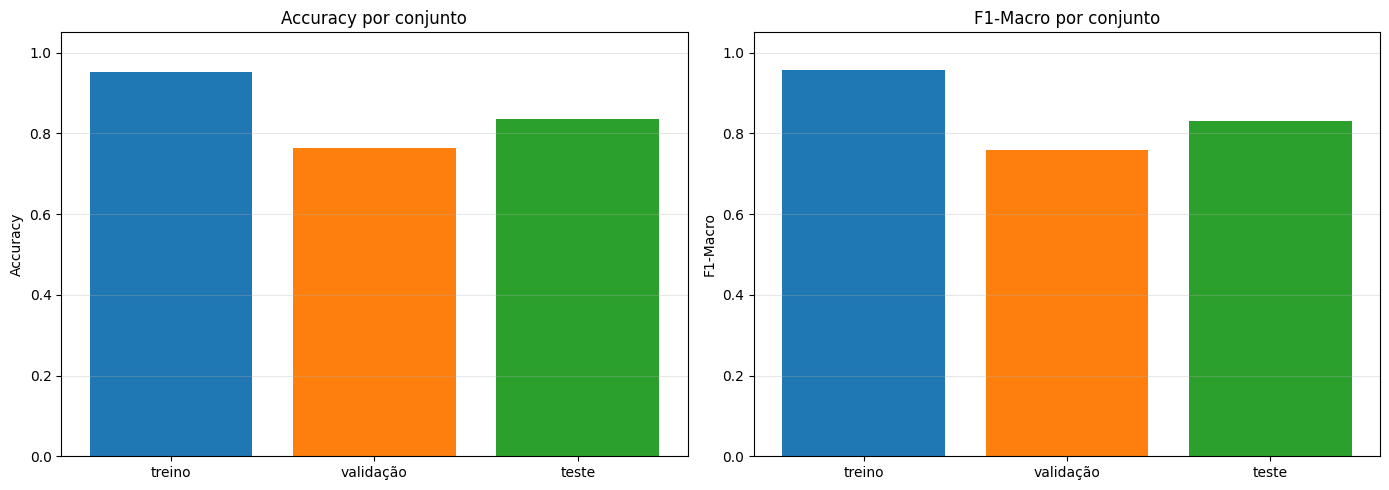


Relatório detalhado no conjunto de teste:
                        precision    recall  f1-score   support

ADMINISTRAÇÃO / OUTROS       0.62      1.00      0.77        23
              EDUCAÇÃO       1.00      0.75      0.86         4
INFRAESTRUTURA / OBRAS       1.00      0.58      0.74        12
            SANEAMENTO       1.00      0.82      0.90        11
                 SAÚDE       1.00      0.96      0.98        23
             SEGURANÇA       1.00      0.58      0.74        12

              accuracy                           0.84        85
             macro avg       0.94      0.78      0.83        85
          weighted avg       0.90      0.84      0.84        85



In [8]:
# ============================================================
# 7. Classificação por macroárea de gasto com TF-IDF + SVM
# ============================================================

import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline

MACROAREAS = [
    'ADMINISTRAÇÃO / OUTROS',
    'EDUCAÇÃO',
    'INFRAESTRUTURA / OBRAS',
    'SANEAMENTO',
    'SAÚDE',
    'SEGURANÇA'
]

def normalizar_orgao_para_rotulo(orgao):
    if pd.isna(orgao):
        return ''
    texto = str(orgao).strip().upper()
    texto = unicodedata.normalize('NFKD', texto).encode('ascii', 'ignore').decode('utf-8')
    return texto

def mapear_orgao_para_macroarea(orgao):
    texto = normalizar_orgao_para_rotulo(orgao)

    if any(chave in texto for chave in ['SAUDE', 'HOSPITAL', 'HEMOCENTRO', 'FARMACIA', 'VIGILANCIA SANITARIA']):
        return 'SAÚDE'

    if any(chave in texto for chave in ['CAESB', 'SANEAMENTO', 'AGUAS', 'ESGOTO']):
        return 'SANEAMENTO'

    if any(chave in texto for chave in ['POLICIA', 'BOMBEIRO', 'DETRAN', 'TRANSITO', 'PENITENCIARIO', 'PENITENCIARIA', 'SEGURANCA', 'MILITAR', 'DEFESA CIVIL']):
        return 'SEGURANÇA'

    if any(chave in texto for chave in ['EDUCACAO', 'UNIVERSIDADE', 'ESCOLA', 'COLEGIO']):
        return 'EDUCAÇÃO'

    if any(chave in texto for chave in ['INFRAESTRUTURA', 'OBRAS', 'RODAGEM', 'DER', 'TRANSPORTE', 'METRO', 'NOVACAP', 'TERRACAP', 'URBANISMO', 'HABITACAO', 'ESTRADAS', 'ILUMINACAO', 'ENERGIA', 'MOBILIDADE']):
        return 'INFRAESTRUTURA / OBRAS'

    return 'ADMINISTRAÇÃO / OUTROS'

svm_df = licitacoes.copy()

# Rótulo fraco gerado a partir do órgão
svm_df['macroarea_gasto'] = svm_df['orgao'].apply(mapear_orgao_para_macroarea)

# Entrada textual do modelo: SEM órgão
svm_df['texto_classificacao'] = (
    svm_df['texto_para_classificacao_area']
    .fillna('')
    .astype(str)
    .str.strip()
)

# Filtro mínimo
svm_df = svm_df[svm_df['texto_classificacao'].str.len() >= 20].copy()

# Garantia extra anti-vazamento
svm_df['vazamento_residual'] = svm_df.apply(
    lambda row: texto_contem_orgao(row['texto_classificacao'], row.get('orgao', '')),
    axis=1
)

print('Registros com vazamento residual antes do treino:', int(svm_df['vazamento_residual'].sum()))

if svm_df['vazamento_residual'].sum() > 0:
    print('Removendo registros com vazamento residual detectado...')
    svm_df = svm_df.loc[~svm_df['vazamento_residual']].copy()

label_encoder = LabelEncoder()
svm_df['label'] = label_encoder.fit_transform(svm_df['macroarea_gasto'])

id2label = {i: label for i, label in enumerate(label_encoder.classes_)}
label2id = {label: i for i, label in id2label.items()}

print('Distribuição das classes por macroárea:')
display(
    svm_df['macroarea_gasto']
    .value_counts()
    .rename_axis('macroarea')
    .reset_index(name='quantidade')
)

print('\nExemplo real do texto usado na classificação (sem órgão):')
print(svm_df['texto_classificacao'].iloc[0][:1000])

train_df, test_df = train_test_split(
    svm_df,
    test_size=0.20,
    random_state=SEED,
    stratify=svm_df['label']
)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.20,
    random_state=SEED,
    stratify=train_df['label']
)

print(f'Tamanho do treino: {len(train_df)}')
print(f'Tamanho da validação: {len(val_df)}')
print(f'Tamanho do teste: {len(test_df)}')

# Pipeline TF-IDF + SVM
pipeline_svm = Pipeline([
    ('tfidf', TfidfVectorizer(
        analyzer='word',
        ngram_range=(1, 2),
        max_features=50000,
        sublinear_tf=True,
        min_df=2
    )),
    ('svm', SVC(
        kernel='linear',
        C=1.0,
        probability=True,
        random_state=SEED
    ))
])

if RUN_TFIDF_SVM_TRAINING:
    print('\nTreinando pipeline TF-IDF + SVM...')
    pipeline_svm.fit(train_df['texto_classificacao'], train_df['label'])
    print('Treinamento concluído.')
else:
    print('RUN_TFIDF_SVM_TRAINING=False: pulando treinamento.')

predicoes_classificacao = {}

def avaliar_dataset_svm(nome, X, y_true_labels):
    y_pred = pipeline_svm.predict(X)
    y_true = y_true_labels

    predicoes_classificacao[nome] = {
        'y_true': y_true,
        'y_pred': y_pred
    }

    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro')

    print('\n' + '=' * 70)
    print(f'Desempenho no conjunto de {nome}')
    print('=' * 70)
    print(classification_report(
        y_true,
        y_pred,
        target_names=list(label_encoder.classes_),
        zero_division=0
    ))

    return {
        'conjunto': nome,
        'accuracy': acc,
        'f1_macro': f1_macro,
        'quantidade': len(y_true)
    }

desempenho_classificacao = pd.DataFrame([
    avaliar_dataset_svm('treino', train_df['texto_classificacao'], train_df['label']),
    avaliar_dataset_svm('validação', val_df['texto_classificacao'], val_df['label']),
    avaliar_dataset_svm('teste', test_df['texto_classificacao'], test_df['label'])
])

print('\nResumo comparativo para diagnóstico de overfitting:')
display(desempenho_classificacao)

acc_treino = desempenho_classificacao.loc[
    desempenho_classificacao['conjunto'] == 'treino',
    'accuracy'
].iloc[0]
acc_validacao = desempenho_classificacao.loc[
    desempenho_classificacao['conjunto'] == 'validação',
    'accuracy'
].iloc[0]
acc_teste = desempenho_classificacao.loc[
    desempenho_classificacao['conjunto'] == 'teste',
    'accuracy'
].iloc[0]

gap_validacao = acc_treino - acc_validacao
gap_teste = acc_treino - acc_teste

print(
    f'Diferença de accuracy treino - validação: {gap_validacao:.4f}\n'
    f'Diferença de accuracy treino - teste: {gap_teste:.4f}'
)

if gap_validacao > 0.10 or gap_teste > 0.10:
    print(
        'Indício de overfitting: o desempenho no treino ficou mais de 10 pontos '
        'percentuais acima da validação ou do teste.'
    )
else:
    print(
        'Não há indício forte de overfitting por accuracy: treino, validação '
        'e teste ficaram próximos.'
    )

# Gráfico de barras com accuracy e F1-Macro por conjunto
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

conjuntos = desempenho_classificacao['conjunto'].tolist()
acuracias = desempenho_classificacao['accuracy'].tolist()
f1s = desempenho_classificacao['f1_macro'].tolist()

axes[0].bar(conjuntos, acuracias, color=['tab:blue', 'tab:orange', 'tab:green'])
axes[0].set_title('Accuracy por conjunto')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1.05)
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(conjuntos, f1s, color=['tab:blue', 'tab:orange', 'tab:green'])
axes[1].set_title('F1-Macro por conjunto')
axes[1].set_ylabel('F1-Macro')
axes[1].set_ylim(0, 1.05)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print('\nRelatório detalhado no conjunto de teste:')
print(classification_report(
    predicoes_classificacao['teste']['y_true'],
    predicoes_classificacao['teste']['y_pred'],
    target_names=list(label_encoder.classes_),
    zero_division=0
))


In [9]:
# ============================================================
# 7.1 Termos mais relevantes por macroárea (TF-IDF + SVM linear)
# ============================================================

if RUN_TFIDF_SVM_TRAINING and 'pipeline_svm' in globals():
    tfidf_vec = pipeline_svm.named_steps['tfidf']
    svm_clf = pipeline_svm.named_steps['svm']
    feature_names = np.array(tfidf_vec.get_feature_names_out())

    print('Termos mais relevantes por macroárea (coeficientes do SVM linear):\n')

    if hasattr(svm_clf, 'coef_'):
        n_classes = svm_clf.coef_.shape[0]
        classes = label_encoder.classes_

        if n_classes == len(classes):
            # classificação multiclasse OvR
            for i, classe in enumerate(classes):
                top_idx = np.argsort(svm_clf.coef_[i])[::-1][:15]
                top_terms = feature_names[top_idx]
                print(f'{classe}:')
                print('  ', ', '.join(top_terms))
                print()
        else:
            # classificação binária ou formato diferente
            for i in range(n_classes):
                top_idx = np.argsort(svm_clf.coef_[i])[::-1][:15]
                top_terms = feature_names[top_idx]
                print(f'Hiperplano {i}:')
                print('  ', ', '.join(top_terms))
                print()
    else:
        print('Coeficientes não disponíveis para este kernel SVM.')
else:
    print('Execute primeiro o treinamento do TF-IDF + SVM (RUN_TFIDF_SVM_TRAINING=True).')


Termos mais relevantes por macroárea (coeficientes do SVM linear):

Hiperplano 0:
   01

Hiperplano 1:
   01

Hiperplano 2:
   01

Hiperplano 3:
   01

Hiperplano 4:
   01

Hiperplano 5:
   01

Hiperplano 6:
   01

Hiperplano 7:
   01

Hiperplano 8:
   01

Hiperplano 9:
   01

Hiperplano 10:
   01

Hiperplano 11:
   01

Hiperplano 12:
   01

Hiperplano 13:
   01

Hiperplano 14:
   01



# Probabilidade de Classe no SVM

No SVM com `probability=True`, as probabilidades de classe são estimadas via **calibração de Platt** (regressão logística ajustada sobre os scores do hiperplano do SVM).

Diferente do BERTimbau, que retorna logits transformados por Softmax, o SVM linear separa as classes por hiperplanos no espaço TF-IDF. A função `predict_proba()` retorna probabilidades calibradas para cada classe, permitindo interpretar a confiança da predição. A classe final é aquela com maior probabilidade calibrada, analogamente à escolha pelo argmax do Softmax.

A calibração de Platt transforma o score de decisão do SVM em uma probabilidade via regressão logística: `P(y=k|x) = sigmoid(A * f(x) + B)`, onde `f(x)` é a distância assinada ao hiperplano e `A`, `B` são parâmetros ajustados por validação cruzada interna.

In [10]:
def prever_categoria_svm(texto):
    """
    Classifica um texto de edital com TF-IDF + SVM e retorna:
    - categoria prevista;
    - probabilidade da categoria (calibração de Platt);
    - distribuição completa das probabilidades.
    """
    probs = pipeline_svm.predict_proba([texto])[0]
    pred_id = int(np.argmax(probs))
    confianca = float(probs[pred_id])
    categoria_prevista = id2label[pred_id]

    probabilidades = {
        id2label[i]: float(probs[i])
        for i in range(len(id2label))
    }

    return categoria_prevista, confianca, probabilidades


In [11]:
# Exemplo explícito de aplicação do predict_proba do SVM
# na tarefa de classificação por macroárea de gasto público.
texto_teste = svm_df['texto_classificacao'].iloc[0]

probs = pipeline_svm.predict_proba([texto_teste])[0]
pred_id = int(np.argmax(probs))

print('Probabilidades calibradas por classe (Platt Scaling):')
for i, prob in enumerate(probs):
    print(f'  {id2label[i]}: {prob:.4f}')
print('Classe prevista:', id2label[pred_id])


Probabilidades calibradas por classe (Platt Scaling):
  ADMINISTRAÇÃO / OUTROS: 0.0017
  EDUCAÇÃO: 0.0030
  INFRAESTRUTURA / OBRAS: 0.0013
  SANEAMENTO: 0.0037
  SAÚDE: 0.9885
  SEGURANÇA: 0.0017
Classe prevista: SAÚDE


In [12]:
texto_teste = licitacoes['texto_para_classificacao_area'].iloc[0]

categoria, confianca, probabilidades = prever_categoria_svm(texto_teste)

print('Macroárea prevista:', categoria)
print('Confiança:', round(confianca, 4))
print('Probabilidades:')
print(probabilidades)


Macroárea prevista: SAÚDE
Confiança: 0.9885
Probabilidades:
{'ADMINISTRAÇÃO / OUTROS': 0.0016955788805427736, 'EDUCAÇÃO': 0.002988117681378814, 'INFRAESTRUTURA / OBRAS': 0.0013186480009481094, 'SANEAMENTO': 0.0037020601392949853, 'SAÚDE': 0.9885499597489852, 'SEGURANÇA': 0.0017456355488501736}


# Diagnóstico de overfitting na classificação por macroárea

A célula abaixo consolida o desempenho de treino, validação e teste na tarefa de classificação por área de gasto público. A comparação entre esses três conjuntos ajuda a verificar overfitting: se o modelo acerta muito no treino, mas cai bastante na validação ou no teste, há sinal de memorização em vez de generalização.

Nesta versão, a interpretação do diagnóstico deve considerar também a auditoria anti-vazamento. Como o texto usado no classificador TF-IDF + SVM foi reconstruído sem o nome do órgão e passou por checagem residual, a comparação entre treino, validação e teste fica mais informativa sobre aprendizado semântico do objeto e do edital.

In [13]:
# ============================================================
# Diagnóstico complementar de overfitting
# ============================================================

if 'desempenho_classificacao' in globals():
    print('Desempenho consolidado: treino x validação x teste')
    display(desempenho_classificacao)

    y_true_teste = predicoes_classificacao['teste']['y_true']
    y_pred_teste = predicoes_classificacao['teste']['y_pred']

    matriz_teste = pd.DataFrame(
        confusion_matrix(y_true_teste, y_pred_teste),
        index=[f'Real: {classe}' for classe in label_encoder.classes_],
        columns=[f'Previsto: {classe}' for classe in label_encoder.classes_]
    )

    print('\nMatriz de confusão no conjunto de teste:')
    display(matriz_teste)

    acc_treino = desempenho_classificacao.loc[
        desempenho_classificacao['conjunto'] == 'treino',
        'accuracy'
    ].iloc[0]
    acc_validacao = desempenho_classificacao.loc[
        desempenho_classificacao['conjunto'] == 'validação',
        'accuracy'
    ].iloc[0]
    acc_teste = desempenho_classificacao.loc[
        desempenho_classificacao['conjunto'] == 'teste',
        'accuracy'
    ].iloc[0]

    print(
        '\nLeitura prática:\n'
        f'- Accuracy no treino: {acc_treino:.4f}\n'
        f'- Accuracy na validação: {acc_validacao:.4f}\n'
        f'- Accuracy no teste: {acc_teste:.4f}\n'
    )

    if acc_treino - min(acc_validacao, acc_teste) > 0.10:
        print(
            'Conclusão: há sinal de overfitting, pois o treino ficou '
            'mais de 10 pontos percentuais acima da validação ou do teste.'
        )
    else:
        print(
            'Conclusão: não há sinal forte de overfitting pela accuracy, '
            'pois treino, validação e teste ficaram relativamente próximos.'
        )

    print('\nObservação metodológica:')
    print(
        'Nesta versão, o texto usado para classificação foi construído sem o nome do órgão, '
        'e uma auditoria explícita de vazamento residual foi executada antes do treino. '
        'O classificador TF-IDF + SVM aprende a partir de frequência de termos (sem embeddings), '
        'o que torna o pipeline mais rápido e interpretável, embora menos capaz de capturar '
        'contexto semântico profundo que modelos Transformer conseguem.'
    )

else:
    print(
        'Execute primeiro a célula de treinamento do TF-IDF + SVM para gerar '
        'desempenho_classificacao e predicoes_classificacao.'
    )


Desempenho consolidado: treino x validação x teste


,conjunto,accuracy,f1_macro,quantidade
0,treino,0.952030,0.956085,271
1,validação,0.764706,0.759152,68
2,teste,0.835294,0.829212,85



Matriz de confusão no conjunto de teste:


,Previsto: ADMINISTRAÇÃO / OUTROS,Previsto: EDUCAÇÃO,Previsto: INFRAESTRUTURA / OBRAS,Previsto: SANEAMENTO,Previsto: SAÚDE,Previsto: SEGURANÇA
Real: ADMINISTRAÇÃO / OUTROS,23,0,0,0,0,0
Real: EDUCAÇÃO,1,3,0,0,0,0
Real: INFRAESTRUTURA / OBRAS,5,0,7,0,0,0
Real: SANEAMENTO,2,0,0,9,0,0
Real: SAÚDE,1,0,0,0,22,0
Real: SEGURANÇA,5,0,0,0,0,7



Leitura prática:
- Accuracy no treino: 0.9520
- Accuracy na validação: 0.7647
- Accuracy no teste: 0.8353

Conclusão: há sinal de overfitting, pois o treino ficou mais de 10 pontos percentuais acima da validação ou do teste.

Observação metodológica:
Nesta versão, o texto usado para classificação foi construído sem o nome do órgão, e uma auditoria explícita de vazamento residual foi executada antes do treino. O classificador TF-IDF + SVM aprende a partir de frequência de termos (sem embeddings), o que torna o pipeline mais rápido e interpretável, embora menos capaz de capturar contexto semântico profundo que modelos Transformer conseguem.


# 9. Definição do resumo em linguagem cidadã

O resumo em linguagem cidadã deve ser curto, direto e fiel ao edital. A proposta é que cada resumo tenha **um parágrafo**, com aproximadamente **80 a 130 palavras**, evitando jargões como “certame”, “objeto licitatório”, “instrumento convocatório” e “adjudicação”, salvo quando indispensáveis.

## Critérios do resumo ideal

O resumo deve conter:

1. **Objeto:** o que será comprado ou contratado.
2. **Órgão:** quem está conduzindo a contratação.
3. **Participação:** quem, em tese, pode participar.
4. **Valor ou escala:** valor homologado, quantidade ou dimensão, quando disponível.
5. **Alerta:** que o edital oficial deve ser consultado para regras completas.

## Exemplo de saída desejada

> Este edital trata da compra de medicamentos para atender necessidades da Secretaria de Estado de Saúde do Distrito Federal. Empresas fornecedoras do setor farmacêutico que cumpram os requisitos do edital podem participar da disputa. O valor informado na base é de R$ 62.800,00. O interessado deve consultar o edital completo para verificar prazos, documentos exigidos, condições de entrega e demais regras da contratação.


In [14]:
# ============================================================
# 7. Baseline simples: resumo por regras
# ============================================================

def resumo_cidadao_baseline(row):
    orgao = row.get('orgao', 'órgão público')
    modalidade = row.get('modalidade', 'licitação')
    objeto = row.get('objeto_limpo', '')
    tipo = row.get('tipo', '')
    valor = row.get('total_homologado', None)

    if pd.isna(valor) or str(valor).strip() == '':
        valor_texto = 'O valor não foi identificado na planilha.'
    else:
        valor_texto = f'O valor informado na base é de R$ {valor}.'

    resumo = (
        f'Este edital é uma {modalidade.lower()} conduzida por {orgao}. '
        f'O objetivo é {objeto.lower()}. '
        f'Fornecedores que atuem com {str(tipo).lower()} e atendam às exigências do edital podem avaliar a participação. '
        f'{valor_texto} '
        f'O interessado deve consultar o edital completo para confirmar prazos, documentos exigidos, condições de entrega e demais regras da contratação.'
    )

    resumo = re.sub(r'\s+', ' ', resumo).strip()
    return resumo


licitacoes['resumo_baseline'] = licitacoes.apply(resumo_cidadao_baseline, axis=1)

display(licitacoes[['no_da_licitacao', 'orgao', 'objeto_limpo', 'resumo_baseline']].head(3))


,no_da_licitacao,orgao,objeto_limpo,resumo_baseline
0,90119/2025,SECRETARIA DE ESTADO DE SAÚDE - DF,PREGÃO ELETRÔNICO - AQUISIÇÃO DOS MEDICAMENTO(...,Este edital é uma pregão conduzida por SECRETA...
1,90115/2025,SECRETARIA DE ESTADO DE SAÚDE - DF,PREGÃO ELETRÔNICO - PROCESSO PARA POTENCIAL CO...,Este edital é uma pregão conduzida por SECRETA...
2,90114/2025,SECRETARIA DE ESTADO DE SAÚDE - DF,PREGÃO ELETRÔNICO - AQUISIÇÃO REGULAR DE INSUM...,Este edital é uma pregão conduzida por SECRETA...


# 10. Estratégia com LLM via engenharia de prompt

Uma estratégia prática para o projeto é usar um LLM com prompt estruturado. O prompt deve impor fidelidade ao edital, linguagem simples, um único parágrafo, proibição de inventar prazos, valores ou exigências não encontrados e aviso de que o resumo não substitui o edital oficial.

Essa abordagem é adequada quando o objetivo é gerar resumos de alta qualidade sem treinar um modelo do zero. O notebook abaixo deixa uma função genérica, sem incluir chave de API. O grupo pode adaptá-la ao provedor escolhido.


In [ ]:
# ============================================================
# 8. Prompt estruturado para LLM
# ============================================================

#PROMPT_LINGUAGEM_CIDADA = '''
#Você é um assistente especializado em transparência pública e linguagem cidadã.

#Tarefa: leia as informações de um edital de contratação pública e gere um resumo executivo em 1 único parágrafo, com linguagem simples, clara e acessível.

#O resumo deve responder, quando a informação estiver disponível:
#1. O que está sendo comprado ou contratado?
#2. Qual órgão conduz a contratação?
#3. Quem pode se interessar em participar?
#4. Há valor, prazo, entrega ou condição importante?
#5. Qual alerta o cidadão ou fornecedor deve observar?

#Regras obrigatórias:
#- Não invente informações ausentes.
#- Não use jargão jurídico desnecessário.
#- Não ultrapasse 130 palavras.
#- Informe que o edital completo deve ser consultado para regras e prazos oficiais.
#- Escreva em português do Brasil.

#Texto do edital ou registro:
#{texto}

#Resumo em linguagem cidadã:
#'''.strip()


#def montar_prompt_linguagem_cidada(texto):
#    texto = limitar_texto(texto, max_chars=12000)
#    return PROMPT_LINGUAGEM_CIDADA.format(texto=texto)


#exemplo_prompt = montar_prompt_linguagem_cidada(licitacoes['texto_minimo_para_resumo'].iloc[0])
#print(exemplo_prompt[:2500])


In [ ]:
# ============================================================
# 9. Função-modelo para uso de API de LLM
# ============================================================
# Esta célula é um esqueleto. Não coloque chaves de API diretamente no notebook.
# Use variáveis de ambiente ou secrets do Colab/GitHub.

# import os
# from openai import OpenAI
#
# client = OpenAI(api_key=os.environ.get('OPENAI_API_KEY'))
#
# def gerar_resumo_llm(texto, modelo='gpt-4o-mini'):
#     prompt = montar_prompt_linguagem_cidada(texto)
#     resposta = client.chat.completions.create(
#         model=modelo,
#         messages=[
#             {'role': 'system', 'content': 'Você resume documentos públicos em linguagem cidadã, com fidelidade e clareza.'},
#             {'role': 'user', 'content': prompt}
#         ],
#         temperature=0.2,
#         max_tokens=220
#     )
#     return resposta.choices[0].message.content.strip()
#
# # Teste em pequena amostra:
# # licitacoes_amostra = licitacoes.head(5).copy()
# # licitacoes_amostra['resumo_llm'] = licitacoes_amostra['texto_minimo_para_resumo'].apply(gerar_resumo_llm)
# # display(licitacoes_amostra[['n_da_licitacao', 'resumo_llm']])


# 12. Sumarização abstrativa com PTT5

Nesta versão, a sumarização local usa **PTT5** fine-tuned para sumarização em português. A tarefa continua sendo gerar um resumo de edital em linguagem cidadã, com foco em clareza, transparência e utilidade para cidadãos e pequenas empresas.

Modelo usado na geração local:

```text
recogna-nlp/ptt5-base-summ
```

Observação metodológica: a sumarização segue sendo uma trilha complementar ao classificador por macroárea. O ideal, em versão final do projeto, é comparar baseline por regras, PTT5 e LLM com prompt estruturado.


In [15]:
# ============================================================
# 12. Sumarização abstrativa local com PTT5
# ============================================================
# Para executar, altere RUN_PTT5_SUMMARIZATION para True.
# PTT5 já ajustado para sumarização em português.
# ============================================================

if RUN_PTT5_SUMMARIZATION:

    import torch
    from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

    # Modelo PTT5 ajustado especificamente para sumarização em português
    PTT5_SUM_MODEL = "recogna-nlp/ptt5-base-summ"

    device = "cuda" if torch.cuda.is_available() else "cpu"

    tokenizer_ptt5 = AutoTokenizer.from_pretrained(PTT5_SUM_MODEL)
    model_ptt5 = AutoModelForSeq2SeqLM.from_pretrained(PTT5_SUM_MODEL).to(device)

    print("Modelo PTT5 carregado:", PTT5_SUM_MODEL)
    print("Dispositivo:", device)

    def limitar_texto_seguro(texto, max_chars=6000):
        """
        Garante que o texto enviado ao modelo não fique excessivamente longo.
        Usa a função limitar_texto, se ela já existir no notebook.
        Caso contrário, aplica um corte simples por caracteres.
        """
        texto = "" if texto is None else str(texto)

        if "limitar_texto" in globals():
            return limitar_texto(texto, max_chars=max_chars)

        return texto[:max_chars]


    def gerar_resumo_ptt5(texto, max_input_tokens=512):
        """
        Gera resumo abstrativo em português usando PTT5 fine-tuned para sumarização.
        Esta função recebe apenas o conteúdo informativo do edital,
        sem prompt longo de instrução, para evitar que o modelo copie o comando.
        """

        if texto is None or len(str(texto).strip()) == 0:
            return "Texto insuficiente para gerar resumo."

        texto = limitar_texto_seguro(texto, max_chars=6000).strip()

        inputs = tokenizer_ptt5(
            texto,
            return_tensors="pt",
            truncation=True,
            max_length=max_input_tokens
        ).to(device)

        with torch.no_grad():
            output_ids = model_ptt5.generate(
                **inputs,
                max_new_tokens=90,
                min_new_tokens=25,
                num_beams=4,
                no_repeat_ngram_size=3,
                repetition_penalty=1.15,
                length_penalty=1.0,
                early_stopping=True
            )

        resumo = tokenizer_ptt5.decode(
            output_ids[0],
            skip_special_tokens=True
        )

        return resumo.strip()


    def obter_valor_linha(linha, possiveis_colunas, padrao=""):
        """
        Busca o valor de uma linha considerando possíveis nomes de colunas.
        Isso deixa o código robusto caso a base use 'Órgão', 'Orgao',
        'orgao', 'Objeto', 'objeto' etc.
        """
        for coluna in possiveis_colunas:
            if coluna in linha.index:
                valor = linha.get(coluna, padrao)

                if pd.notna(valor):
                    return str(valor).strip()

        return padrao


    def gerar_texto_base_edital(linha):
        """
        Monta um texto informativo limpo a partir dos campos principais da licitação.
        Esse texto será enviado ao PTT5 para sumarização.
        """

        orgao = obter_valor_linha(
            linha,
            ["Órgão", "Orgao", "orgao", "orgao_nome", "nome_orgao", "unidade", "Unidade"],
            "órgão não informado"
        )

        modalidade = obter_valor_linha(
            linha,
            ["Modalidade", "modalidade"],
            "modalidade não informada"
        )

        situacao = obter_valor_linha(
            linha,
            ["Situação", "Situacao", "situacao"],
            "situação não informada"
        )

        tipo = obter_valor_linha(
            linha,
            ["Tipo", "tipo"],
            "tipo não informado"
        )

        objeto = obter_valor_linha(
            linha,
            ["Objeto", "objeto", "descricao", "Descrição", "Descricao"],
            "objeto não informado"
        )

        texto_base = f"""
        Órgão responsável: {orgao}.
        Modalidade da contratação: {modalidade}.
        Situação da licitação: {situacao}.
        Tipo de contratação: {tipo}.
        Objeto do edital: {objeto}.
        """

        return texto_base.strip()


    def gerar_resumo_cidadao_com_ptt5(linha):
        """
        Usa o PTT5 para resumir o conteúdo principal do edital
        e depois organiza a saída em linguagem cidadã.
        """

        orgao = obter_valor_linha(
            linha,
            ["Órgão", "Orgao", "orgao", "orgao_nome", "nome_orgao", "unidade", "Unidade"],
            "órgão não informado"
        )

        modalidade = obter_valor_linha(
            linha,
            ["Modalidade", "modalidade"],
            "modalidade não informada"
        )

        objeto = obter_valor_linha(
            linha,
            ["Objeto", "objeto", "descricao", "Descrição", "Descricao"],
            "objeto não informado"
        )

        texto_base = gerar_texto_base_edital(linha)

        resumo_modelo = gerar_resumo_ptt5(texto_base)

        resumo_cidadao = (
            f"O edital é conduzido por {orgao}, na modalidade {modalidade}. "
            f"Em linguagem simples, a contratação trata de {resumo_modelo.lower()} "
            f"Antes de participar, o interessado deve consultar o edital completo "
            f"para verificar prazos, documentos exigidos, condições de participação, "
            f"critérios de julgamento e regras de entrega."
        )

        return resumo_cidadao


    # ============================================================
    # Teste com a primeira licitação da base
    # ============================================================

    linha_teste = licitacoes.iloc[0]

    texto_base_teste = gerar_texto_base_edital(linha_teste)
    resumo_ptt5_teste = gerar_resumo_ptt5(texto_base_teste)
    resumo_cidadao_teste = gerar_resumo_cidadao_com_ptt5(linha_teste)

    print("\nTexto enviado ao PTT5:")
    print(texto_base_teste)

    print("\nResumo bruto gerado pelo PTT5:")
    print(resumo_ptt5_teste)

    print("\nResumo final em linguagem cidadã:")
    print(resumo_cidadao_teste)

else:
    print(
        "Sumarização com PTT5 não executada. "
        "Para gerar resumos com PTT5, altere RUN_PTT5_SUMMARIZATION para True."
    )

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/780 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.40k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/756k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.20k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/142 [00:00<?, ?B/s]

Modelo PTT5 carregado: recogna-nlp/ptt5-base-summ
Dispositivo: cuda

Texto enviado ao PTT5:
Órgão responsável: SECRETARIA DE ESTADO DE SAÚDE - DF.
        Modalidade da contratação: PREGÃO.
        Situação da licitação: DIVULGADO.
        Tipo de contratação: MATERIAL.
        Objeto do edital: OBJETO: PREGÃO ELETRÔNICO -  AQUISIÇÃO DOS MEDICAMENTO(S) PERTENCENTE(S) AO(S) GRUPO: 09.L.01.B - ANTIMETABÓLITOS E GRUPO: 09.L.01.X - OUTROS AGENTES ANTINEOPLÁSICOS, EM SISTEMA DE REGISTRO DE PREÇOS, PARA ATENDER ÀS NECESSIDADES DA SECRETARIA DE SAÚDE   DF, CONFORME ESPECIFICAÇÕES E QUANTITATIVOS CONSTANTES NO ANEXO I DO EDITAL..

Resumo bruto gerado pelo PTT5:
PREGÃO: SECRETARIA DE ESTADO DE SAÚDE - DF. Objeto do edital: AQUISIÇÃO DOS MEDICAMENTO(S) PERTENCENTE(S).

Resumo final em linguagem cidadã:
O edital é conduzido por SECRETARIA DE ESTADO DE SAÚDE - DF, na modalidade PREGÃO. Em linguagem simples, a contratação trata de pregão: secretaria de estado de saúde - df. objeto do edital: aquisi

# 12. Criação de base de avaliação

Para avaliar a qualidade dos resumos, recomenda-se criar uma amostra manualmente anotada. Por exemplo:

- selecionar 50 a 100 editais;
- produzir manualmente um resumo de referência para cada um;
- comparar os resumos gerados com as referências.

## Métricas automáticas sugeridas

- **ROUGE-1:** sobreposição de unigramas com resumo de referência.
- **ROUGE-2:** sobreposição de bigramas.
- **ROUGE-L:** similaridade baseada em maior subsequência comum.
- **BERTScore ou similaridade semântica:** se o grupo optar por embeddings.

## Avaliação qualitativa sugerida

Criar uma rubrica de 1 a 5 para clareza, fidelidade, completude, ausência de alucinação e utilidade para cidadão ou pequeno fornecedor.


In [ ]:
# ============================================================
# 11. Estrutura para avaliação com ROUGE
# ============================================================
# É necessário ter uma coluna de resumo de referência, criada manualmente.

# from rouge_score import rouge_scorer
#
# def calcular_rouge(referencia, gerado):
#     scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
#     scores = scorer.score(str(referencia), str(gerado))
#     return {
#         'rouge1_f': scores['rouge1'].fmeasure,
#         'rouge2_f': scores['rouge2'].fmeasure,
#         'rougeL_f': scores['rougeL'].fmeasure,
#     }
#
# # aval = licitacoes_avaliacao.dropna(subset=['resumo_referencia', 'resumo_llm']).copy()
# # metricas = aval.apply(lambda r: calcular_rouge(r['resumo_referencia'], r['resumo_llm']), axis=1)
# # metricas_df = pd.DataFrame(list(metricas))
# # display(metricas_df.describe())


# 13. Análise de legibilidade e linguagem cidadã

Além de comparar com resumos de referência, o grupo pode medir características objetivas do texto gerado:

- número de palavras;
- número de frases;
- tamanho médio das frases;
- presença de termos técnicos;
- presença de alerta para consultar o edital completo;
- presença de objeto, órgão, valor e público interessado.

Essas medidas ajudam a demonstrar que o resumo ficou mais acessível do que o edital original.


In [16]:
# ============================================================
# 12. Métricas simples de legibilidade
# ============================================================

TERMOS_TECNICOS = [
    'certame', 'adjudicação', 'homologação', 'instrumento convocatório',
    'contratante', 'contratada', 'habilitação', 'impugnação', 'sanções administrativas'
]


def metricas_legibilidade(texto):
    texto = str(texto)
    palavras = re.findall(r'\w+', texto.lower())
    frases = re.split(r'[.!?]+', texto)
    frases = [f.strip() for f in frases if f.strip()]

    n_palavras = len(palavras)
    n_frases = len(frases)
    media_palavras_frase = n_palavras / max(n_frases, 1)
    termos_encontrados = [t for t in TERMOS_TECNICOS if t in texto.lower()]

    return {
        'n_palavras': n_palavras,
        'n_frases': n_frases,
        'media_palavras_por_frase': media_palavras_frase,
        'n_termos_tecnicos': len(termos_encontrados),
        'termos_tecnicos': ', '.join(termos_encontrados)
    }


metricas_baseline = licitacoes['resumo_baseline'].head(10).apply(metricas_legibilidade)
metricas_baseline_df = pd.DataFrame(list(metricas_baseline))
display(metricas_baseline_df.describe())


,n_palavras,n_frases,media_palavras_por_frase,n_termos_tecnicos
count,10.0,10.000000,10.0,10.0
mean,0.0,9.400000,0.0,0.0
std,0.0,3.470511,0.0,0.0
min,0.0,6.000000,0.0,0.0
25%,0.0,6.250000,0.0,0.0
50%,0.0,8.000000,0.0,0.0
75%,0.0,12.750000,0.0,0.0
max,0.0,15.000000,0.0,0.0


# 14. Produto final esperado

O produto final do projeto pode ser uma tabela com os seguintes campos:

- `n_da_licitacao`;
- `orgao`;
- `modalidade`;
- `situacao`;
- `tipo`;
- `objeto_limpo`;
- `edital`;
- `texto_extraido`;
- `resumo_baseline`;
- `resumo_transformer` ou `resumo_llm`;
- métricas de legibilidade;
- avaliação manual.

A saída pode ser salva como CSV ou Parquet e disponibilizada no repositório do GitHub.


In [17]:
# ============================================================
# 13. Exportação de uma versão inicial com resumos baseline
# ============================================================

colunas_saida = [
    'no_da_licitacao',
    'modalidade',
    'situacao',
    'orgao',
    'macroarea_gasto',
    'codigo_comprasnet',
    'tipo',
    'objeto_limpo',
    'edital',
    'total_homologado',
    'total_homologado_num',
    'resumo_baseline'
]

saida = licitacoes.merge(
    svm_df[['no_da_licitacao', 'macroarea_gasto']].drop_duplicates(),
    on='no_da_licitacao',
    how='left'
)

saida = saida[colunas_saida].copy()
saida_path = PROCESSED_DIR / 'resumos_editais_linguagem_cidada_baseline.csv'
saida.to_csv(saida_path, index=False, encoding='utf-8-sig')

print('Arquivo exportado:', saida_path)
display(saida.head())


Arquivo exportado: data/processed/resumos_editais_linguagem_cidada_baseline.csv


,no_da_licitacao,modalidade,situacao,orgao,macroarea_gasto,codigo_comprasnet,tipo,objeto_limpo,edital,total_homologado,total_homologado_num,resumo_baseline
0,90119/2025,PREGÃO,DIVULGADO,SECRETARIA DE ESTADO DE SAÚDE - DF,SAÚDE,926119,MATERIAL,PREGÃO ELETRÔNICO - AQUISIÇÃO DOS MEDICAMENTO(...,http://www.comprasnet.gov.br/ConsultaLicitacoe...,"62.800,00",62800.0,Este edital é uma pregão conduzida por SECRETA...
1,90115/2025,PREGÃO,DIVULGADO,SECRETARIA DE ESTADO DE SAÚDE - DF,SAÚDE,926119,MATERIAL,PREGÃO ELETRÔNICO - PROCESSO PARA POTENCIAL CO...,http://www.comprasnet.gov.br/ConsultaLicitacoe...,"607.671,00",607671.0,Este edital é uma pregão conduzida por SECRETA...
2,90114/2025,PREGÃO,DIVULGADO,SECRETARIA DE ESTADO DE SAÚDE - DF,SAÚDE,926119,MATERIAL,PREGÃO ELETRÔNICO - AQUISIÇÃO REGULAR DE INSUM...,http://www.comprasnet.gov.br/ConsultaLicitacoe...,"188.808,00",188808.0,Este edital é uma pregão conduzida por SECRETA...
3,90113/2025,PREGÃO,DIVULGADO,SECRETARIA DE ESTADO DE SAÚDE - DF,SAÚDE,926119,MATERIAL,PREGÃO ELETRÔNICO - AQUISIÇÃO DE CAPELA DE FLU...,http://www.comprasnet.gov.br/ConsultaLicitacoe...,"74.400,00",74400.0,Este edital é uma pregão conduzida por SECRETA...
4,90109/2025,PREGÃO,DIVULGADO,SECRETARIA DE ESTADO DE SAÚDE - DF,SAÚDE,926119,MATERIAL,PREGÃO ELETRÔNICO - AQUISIÇÃO REGULAR DE INSUM...,http://www.comprasnet.gov.br/ConsultaLicitacoe...,"11.278,00",11278.0,Este edital é uma pregão conduzida por SECRETA...


# 15. Metodologia proposta para o relatório final

## 15.1 Coleta

A coleta parte da planilha de licitações públicas de 2025. O script carrega os links dos editais, realiza o download dos documentos acessíveis e registra falhas. A coleta é limitada aos editais disponíveis publicamente e respeita boas práticas de acesso automatizado.

## 15.2 Pré-processamento

Os documentos são limpos e convertidos em texto. Removem-se ruídos evidentes, como espaços duplicados, caracteres de controle, rodapés repetitivos e trechos não textuais. Textos muito longos são divididos ou reduzidos para caber no contexto do modelo.

## 15.3 Modelagem

Serão exploradas quatro frentes:

1. **Baseline de classificação:** TF-IDF + Regressão Logística para prever a macroárea de gasto.
2. **TF-IDF + SVM:** pipeline clássico de ML para classificar editais por macroárea (Saúde, Saneamento, Educação etc.), com features lexicais e kernel linear.
3. **Transformer/Seq2Seq para sumarização:** PTT5 para resumo em linguagem cidadã.
4. **LLM com prompt estruturado:** geração controlada de resumo, eventualmente comparada ao PTT5.

## 15.4 Avaliação

A avaliação da classificação combinará accuracy, F1 macro e matriz de confusão. A avaliação da sumarização combinará métricas automáticas e avaliação humana. Para uma amostra de editais, o grupo produzirá resumos de referência e comparará os modelos com ROUGE e rubrica qualitativa. A avaliação humana será especialmente importante para medir fidelidade, clareza e ausência de alucinação.

## 15.5 Discussão crítica

A discussão final deve abordar risco de simplificação excessiva, risco de alucinação por LLMs, necessidade de manter link para o edital oficial, limites de extração de PDFs e impacto potencial para transparência e controle social.


# 16. Riscos, vieses e uso responsável

O sistema deve ser apresentado como ferramenta auxiliar, não como substituto do edital oficial. O resumo pode facilitar a triagem, mas a decisão de participar de uma licitação depende da leitura integral do documento.

## Principais riscos

- **Alucinação:** o modelo pode incluir informação que não está no edital.
- **Omissão:** o resumo pode deixar de mencionar uma exigência importante.
- **Simplificação excessiva:** linguagem simples não pode alterar o sentido jurídico do documento.
- **Viés de acesso:** documentos escaneados ou mal formatados podem ser menos bem processados.
- **Dependência tecnológica:** uso de API externa pode gerar custo, limite de chamadas e questões de privacidade.

## Mitigações

- incluir regra para não inventar informação;
- manter link para o edital original;
- registrar confiança/qualidade do resumo;
- aplicar avaliação humana em amostra;
- comparar baseline, Transformer e LLM;
- documentar limitações de coleta e extração.


# 17. Estrutura sugerida do repositório

```text
sumarizacao-editais-linguagem-cidada/
│
├── README.md
├── requirements.txt
├── notebooks/
│   └── projeto_final_pln_sumarizacao_editais.ipynb
├── data/
│   ├── licitacoes2025.csv
│   ├── raw_editais/
│   └── processed/
│       └── resumos_editais_linguagem_cidada_baseline.csv
├── src/
│   ├── coleta_editais.py
│   ├── preprocessamento.py
│   ├── sumarizacao.py
│   └── avaliacao.py
└── slides/
    └── apresentacao_final.pdf
```

## Nome sugerido para o repositório

`sumarizacao-editais-linguagem-cidada`

## Descrição curta

> Projeto de PLN para resumir editais de contratação pública em linguagem cidadã, usando scraping, Transformers, LLMs e avaliação de clareza, fidelidade e utilidade pública.


# 18. Roteiro sugerido para apresentação de 10 minutos

1. **Problema real:** editais são públicos, mas pouco compreensíveis.
2. **Objetivo:** gerar resumos em linguagem cidadã.
3. **Dados:** planilha de licitações e links dos editais.
4. **Coleta:** scraping/download e extração de texto.
5. **Métodos:** baseline, Transformer/Seq2Seq e LLM com prompt.
6. **Avaliação:** ROUGE, legibilidade e rubrica humana.
7. **Resultados esperados:** resumos mais curtos, claros e úteis.
8. **Limitações:** alucinação, PDFs ruins, ausência de prazo em alguns registros.
9. **Impacto:** transparência, controle social e apoio a pequenos fornecedores.
10. **Próximos passos:** interface web, API pública e integração com portais de compras.


# 19. Referências iniciais para fundamentação

Referências diretamente relacionadas ao código atualizado:

1. **TF-IDF + SVM** — Joachims, T. *Text Categorization with Support Vector Machines: Learning with Many Relevant Features*. ECML 1998. Pipeline clássico de classificação textual, implementado via `sklearn.pipeline.Pipeline` com `TfidfVectorizer` e `SVC`.

2. **scikit-learn** — Pedregosa et al. *Scikit-learn: Machine Learning in Python*. JMLR 12, 2011. Documentação: https://scikit-learn.org

3. **PTT5** — Carmo, Piau, Campiotti, Nogueira e Lotufo. *PTT5: Pretraining and validating the T5 model on Brazilian Portuguese data*.

4. **Base do projeto no GitHub** — `primodeckers/deep-learning-pln-project`, especialmente `data/raw/licitacoes2025.csv` e `docs/PROPOSALS.md`.

5. Artigos sobre linguagem cidadã, transparência pública, simplificação textual e acessibilidade da informação governamental.

6. Literatura sobre weak supervision e weak labeling, relevante porque a macroárea é inferida inicialmente a partir do órgão, com posterior validação manual em amostra.

# 20. Conclusão da proposta

A proposta de **Sumarização de Editais para Linguagem Cidadã** é adequada ao projeto final porque combina um problema público real, dados textuais coletáveis, aplicação concreta de PLN e discussão crítica sobre impacto social.

O projeto não se limita à execução técnica de um modelo. Ele busca demonstrar como técnicas de Deep Learning e PLN podem melhorar a transparência, reduzir barreiras de compreensão e apoiar a participação de cidadãos e pequenos fornecedores nas contratações públicas.

O resultado esperado é um pipeline reprodutível que transforme editais extensos e técnicos em resumos curtos, claros, fiéis e úteis, sempre preservando o link para o edital oficial e reconhecendo os limites do uso de IA generativa em contexto público.
